In [54]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from skimage import util, filters, morphology, color
from skimage.restoration import inpaint_biharmonic
from skimage.segmentation import watershed
from skimage.measure import label

from matplotlib import cm

from stm_voronoi_mst import img_file, gray_process, voronoi_tree, find_nodes, statistics

In [55]:
# ==================
# PARAMETERS
# ==================
f = r"sample_scale_53.png"

# ==================
# GRAYSCALE PROCESS
# ==================
dsize = 11
cutoff = 0.5


C:\Users\Matth\AppData\Local\Temp\ipykernel_23116\320014197.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('afmhot')
C:\Users\Matth\AppData\Local\Temp\ipykernel_23116\320014197.py:28: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = morphology.remove_small_objects(binary, min_size = 64)
C:\Users\Matth\AppData\Local\Temp\ipykernel_23116\320014197.py:29: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be rem

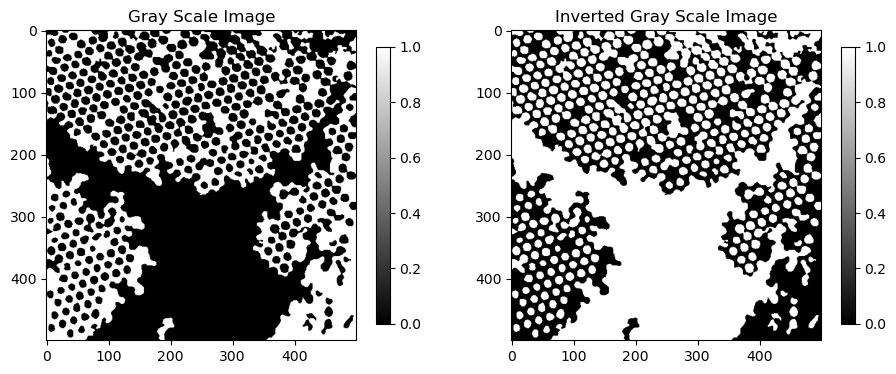

In [56]:
img = img_file(f)
img.load()

img2d = img.img if img.img.ndim == 2 else img.img.mean(axis = 2)
row_means = img2d.mean(axis = 1)
row_devs = np.abs(img2d - row_means[:, None])

max_dev_per_row = row_devs.max(axis = 1)
threshold = max_dev_per_row.mean() + 0.9 * max_dev_per_row.std()
scarred_rows = max_dev_per_row > threshold

mask = np.zeros(img2d.shape, dtype = bool)
mask [scarred_rows, :] = True

inpainted = np.stack([inpaint_biharmonic(img.img[..., c], mask) for c in range(img.img.shape[2])], axis = -1)
source = (inpainted if hasattr(img, 'inpainted') else img.img)
img.img_blurred = filters.gaussian(source, sigma = 2, channel_axis = -1 if source.ndim == 3 else None)
image_gray = np.dot(img.img_blurred[..., :3], [0.2989, 0.5870, 0.1140])
image_norm = (image_gray - image_gray.min()) / (image_gray.max() - image_gray.min())

cmap = cm.get_cmap('afmhot')
colored_image = cmap(image_norm)

img_gr = gray_process(colored_image, dsize = dsize, cutoff = cutoff)

img_gr = np.dot(colored_image[..., :3], [0.2989, 0.5870, 0.1140])
binary = img_gr > filters.threshold_otsu(img_gr)
cleaned = morphology.remove_small_objects(binary, min_size = 64)
cleaned = morphology.remove_small_holes(cleaned, area_threshold = 64)
img_pr = util.invert(cleaned)

fig, ax = plt.subplots(1, 2, figsize = (11, 6))
im0 = ax[0].imshow(cleaned, cmap = 'gray')
ax[0].set_title('Gray Scale Image')
im1 = ax[1].imshow(img_pr, cmap = 'gray')
ax[1].set_title('Inverted Gray Scale Image')

fig.colorbar(im0, ax = ax[0], shrink = 0.6)
fig.colorbar(im1, ax = ax[1], shrink = 0.6)

Text(0.5, 1.0, 'Segmenation Overlayed On Data')

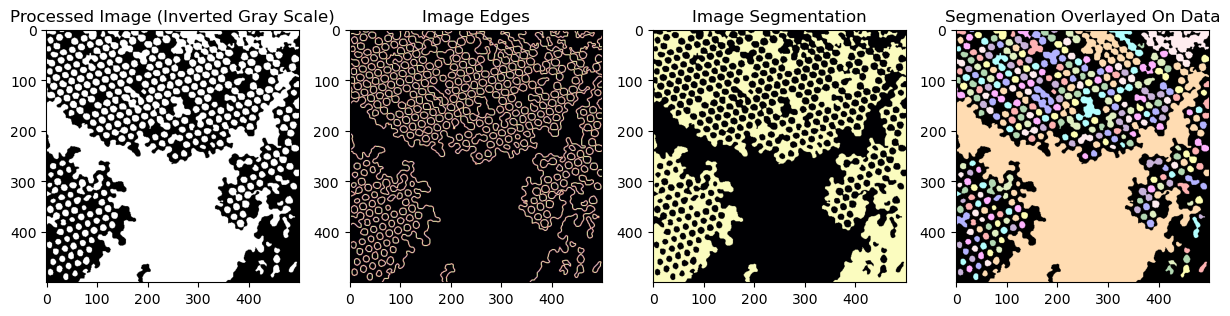

In [57]:
smooth = False

if smooth:
    smoothed = filters.gaussian(img_pr, sigma = 2)
    edges = filters.sobel(smoothed)
else:
    edges = filters.sobel(img_pr)

markers = np.zeros_like(img_pr, dtype = np.int32)
markers [img_pr == 0.0] = 2
markers [img_pr == 1.0] = 1

segmentation = watershed(edges, markers)
label_mask, Nlabel = label(segmentation, background = 2, return_num = True)
img_label_overlay = color.label2rgb(label_mask, image = img_pr)

fig, ax = plt.subplots(1, 4, figsize = (15, 10))
ax[0].imshow(img_pr, cmap = 'gray')
ax[0].set_title('Processed Image (Inverted Gray Scale)')

ax[1].imshow(edges, cmap = 'magma', vmax = np.percentile(edges, 90))
ax[1].set_title('Image Edges')

ax[2].imshow(segmentation, cmap = 'magma')
ax[2].set_title('Image Segmentation')

ax[3].imshow(img_label_overlay)
ax[3].set_title('Segmenation Overlayed On Data')    

In [58]:
graph_node, n = find_nodes(label_mask, Nlabel, 1, img.scale)

img_vor_t, img_vor_deg_t, v_border, graph_node, graph_inner, p, k_1 = voronoi_tree(img, graph_node, k = 24, power = 0.3)

g_msf = nx.minimum_spanning_tree(graph_inner, weight = 'dis')

Text(0.5, 1.0, 'Voronoi Overlay (Original)')

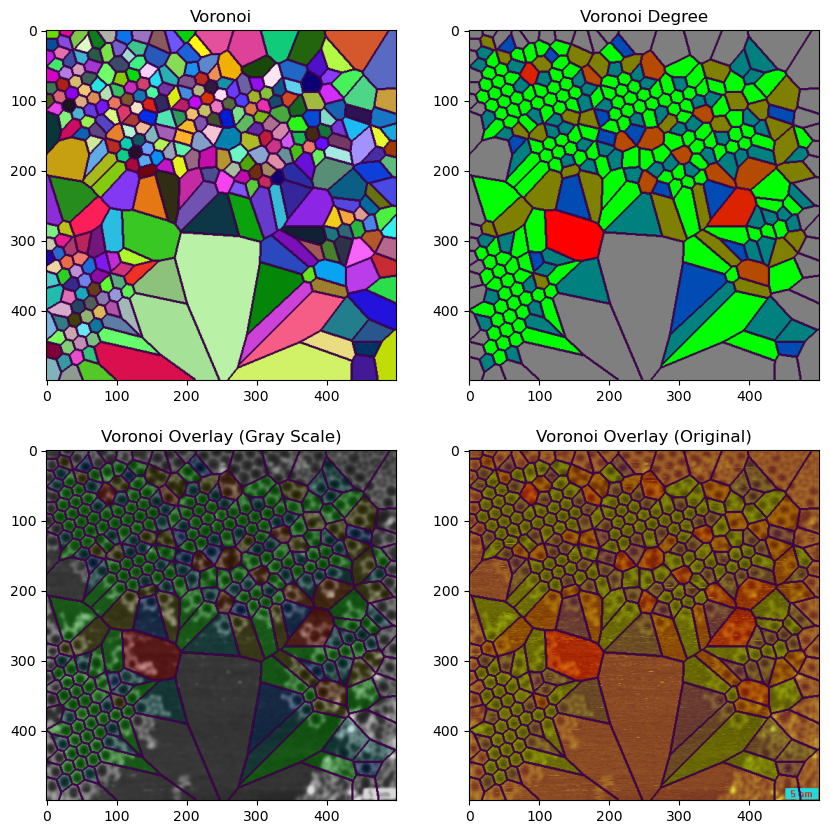

In [59]:
fig, ax = plt.subplots(2, 2, figsize = (10, 10))
ax[0, 0].imshow(img_vor_t)
ax[0, 0].imshow(v_border)
ax[0, 0].set_title('Voronoi')

ax[0, 1].imshow(img_vor_deg_t)
ax[0, 1].imshow(v_border)
ax[0, 1].set_title('Voronoi Degree')

ax[1, 0].imshow(img_gr, cmap = 'gray')
ax[1, 0].imshow(img_vor_deg_t, alpha = 0.25)
ax[1, 0].imshow(v_border)
ax[1, 0].set_title('Voronoi Overlay (Gray Scale)')

ax[1, 1].imshow(img.img)
ax[1, 1].imshow(img_vor_deg_t, alpha = 0.25)
ax[1, 1].imshow(v_border)
ax[1, 1].set_title('Voronoi Overlay (Original)')

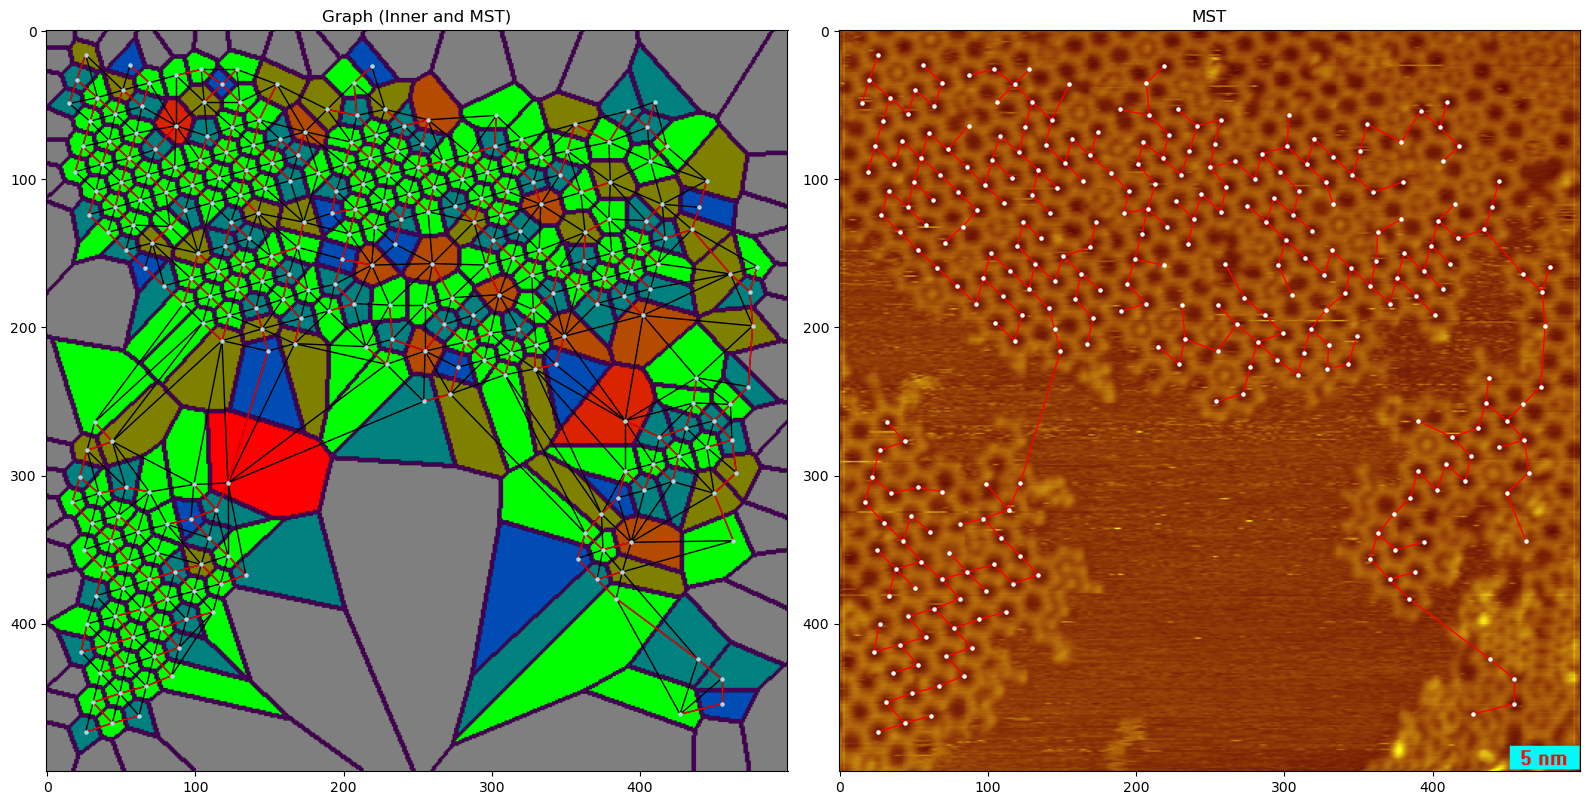

In [60]:
pos = {n:d['pixel_pos'] for n, d in graph_inner.nodes(data = True)}
pos_inner = {node:[dat['pixel_pos'][1], dat['pixel_pos'][0]] for node, dat in graph_inner.nodes(data = True)}
pos_msf = {node:[dat['pixel_pos'][1], dat['pixel_pos'][0]] for node, dat in g_msf.nodes(data = True)}

fig, ax = plt.subplots(1, 2, figsize = (16, 32))

ax[0].imshow(img_vor_deg_t)
ax[0].imshow(v_border)
ax[0].set_title('Graph (Inner and MST)')

xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()

nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'lightblue', node_size = 5, ax = ax[0], hide_ticks = False)
nx.draw_networkx_edges(graph_inner, pos_inner, edge_color = 'black', ax = ax[0], hide_ticks = False)

nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', ax = ax[0], hide_ticks = False)

ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)

ax[1].imshow(img.img)
ax[1].set_title('MST')
nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'white', node_size = 5, ax = ax[1], hide_ticks = False)
nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', ax = ax[1], hide_ticks = False)

ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)

plt.tight_layout()
plt.show()